# Lecture 15: Quantum-Encoded Text Classification (Capstone)

### Where the two halves of this course meet

This course has two arcs that have run in parallel:

- **Quantum** (Lectures 1–11): states as vectors, gates as matrices, and finally
  a *variational quantum classifier* trained with PennyLane (Lecture 11).
- **AI / embeddings** (Lectures 12–14): real text becomes vectors, and meaning
  is measured with inner products (Lecture 12).

Both halves are **linear algebra**. This capstone connects them directly: we
take **real sentence embeddings** (Lecture 12), compress them with **PCA**
(Lecture 13), and feed them into the **quantum classifier** from Lecture 11 —
a model that classifies *language* on a (simulated) quantum circuit.

We also do the honest thing and compare against a classical baseline. The point
is the **bridge**, not a quantum advantage — see `METHODOLOGY.md` Tier C: there
is no demonstrated quantum advantage at this scale, and this notebook shows
exactly that while making the connection concrete and runnable.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(0)
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print('embedding dim:', embed_model.get_embedding_dimension())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding dim: 384


## A small labelled text dataset

Two topics — **quantum/physics** vs **finance/markets** — with no shared
vocabulary cue beyond meaning. The model must learn the boundary from the
geometry of the embeddings.

In [2]:
quantum_texts = [
    'A qubit can exist in a superposition of states.',
    'Entanglement correlates the outcomes of distant particles.',
    'Measuring a quantum state collapses its wavefunction.',
    'Quantum gates are unitary matrices acting on qubits.',
    'The Bloch sphere represents a single qubit state.',
    'Interference lets quantum algorithms cancel wrong answers.',
    'A Hadamard gate creates an equal superposition.',
    'Decoherence destroys fragile quantum information.',
    'Shor algorithm factors integers on a quantum computer.',
    'Quantum error correction protects logical qubits.',
    'Tensor products describe multi-qubit systems.',
    'The Pauli matrices generate single-qubit rotations.',
    'Quantum supremacy demonstrates a hard sampling task.',
    'Photons can carry quantum information as flying qubits.',
    'A controlled-NOT gate entangles two qubits.',
]
finance_texts = [
    'The central bank raised interest rates again.',
    'Stock prices fell sharply after the earnings report.',
    'Investors rotated into bonds amid market volatility.',
    'The hedge fund shorted the overvalued equity.',
    'Inflation eroded the purchasing power of savings.',
    'The IPO was priced above its expected range.',
    'Quarterly revenue beat analyst expectations.',
    'The portfolio was rebalanced to reduce risk.',
    'Mortgage rates climbed to a multi-year high.',
    'The currency weakened against the dollar.',
    'Dividends were increased after strong cash flow.',
    'The merger created a new market leader.',
    'Credit spreads widened during the sell-off.',
    'The commodity rally lifted energy stocks.',
    'Retail sales data moved the futures market.',
]
texts = quantum_texts + finance_texts
y = np.array([1]*len(quantum_texts) + [-1]*len(finance_texts))  # +1 quantum, -1 finance
print(len(texts), 'sentences')

30 sentences


## Embed, compress (PCA), and scale to angles

Each sentence becomes a 384-dim unit vector (Lecture 12). A qubit circuit can't
take 384 inputs, so we **reduce to `n_qubits` dimensions with PCA** — an
eigen-decomposition (Lecture 8's matrices again) that keeps the directions of
greatest variance. Then we scale those coordinates into rotation angles, exactly
as in Lecture 11.

In [3]:
n_qubits = 3
E = embed_model.encode(texts, normalize_embeddings=True)
Xr = PCA(n_components=n_qubits, random_state=0).fit_transform(E)   # 384 -> n_qubits
X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(Xr)        # -> angles

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print('train', Xtr.shape, ' test', Xte.shape)

train (21, 3)  test (9, 3)


## The quantum classifier (from Lecture 11)

Same recipe: angle-encode the (reduced) embedding, apply a trainable entangling
ansatz, read out $\langle Z \rangle$ on the first qubit.

In [4]:
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def circuit(weights, x):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

def model(weights, bias, x):
    return circuit(weights, x) + bias

def cost(weights, bias, X, Y):
    preds = [model(weights, bias, x) for x in X]
    return np.mean((Y - qml.math.stack(preds)) ** 2)

def accuracy(weights, bias, X, Y):
    preds = [np.sign(model(weights, bias, x)) for x in X]
    return float(np.mean(np.array(preds) == Y))

## Train the quantum model on language

In [5]:
shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = 0.01 * np.random.randn(*shape, requires_grad=True)
bias = np.array(0.0, requires_grad=True)
opt = qml.AdamOptimizer(0.1)
batch = 8

for it in range(40):
    idx = np.random.randint(0, len(Xtr), (batch,))
    weights, bias = opt.step(lambda w, b: cost(w, b, Xtr[idx], ytr[idx]), weights, bias)
    if it % 8 == 0 or it == 39:
        print(f'iter {it:2d} | cost {cost(weights, bias, Xtr, ytr):.4f}'
              f' | train acc {accuracy(weights, bias, Xtr, ytr):.2f}')

q_test_acc = accuracy(weights, bias, Xte, yte)
print(f'\nQUANTUM test accuracy: {q_test_acc:.2f}')

iter  0 | cost 1.5054 | train acc 0.38


iter  8 | cost 0.3266 | train acc 0.90


iter 16 | cost 0.3239 | train acc 0.90


iter 24 | cost 0.2110 | train acc 0.95


iter 32 | cost 0.1630 | train acc 1.00


iter 39 | cost 0.0818 | train acc 1.00

QUANTUM test accuracy: 1.00


## Honest baseline: classical logistic regression

A one-line classical classifier on the **same PCA features**. If quantum had a
real edge here, it would beat this — it won't, and that's the expected,
honest result at this scale (Tier C of `METHODOLOGY.md`).

In [6]:
clf = LogisticRegression().fit(Xtr, ytr)
c_test_acc = clf.score(Xte, yte)
print(f'classical  test accuracy: {c_test_acc:.2f}')
print(f'quantum    test accuracy: {q_test_acc:.2f}')
print('\nBoth solve this easily; the quantum model is a faithful bridge,',
      'not a faster one. That is the honest takeaway.')

classical  test accuracy: 1.00
quantum    test accuracy: 1.00

Both solve this easily; the quantum model is a faithful bridge, not a faster one. That is the honest takeaway.


## Visualize: language laid out in quantum-input space

Projecting the first two PCA dimensions shows the two topics already separate
as directions — which is *why* both classifiers succeed. Meaning became
geometry (Lecture 12), and geometry is what the quantum circuit consumes.

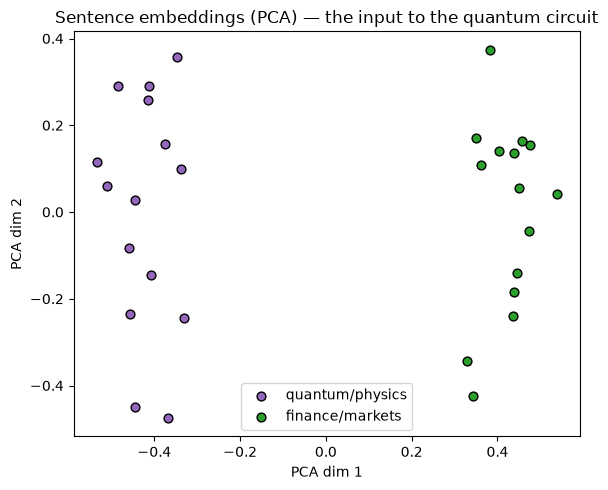

In [7]:
plt.figure(figsize=(6, 5))
m = (y == 1)
plt.scatter(Xr[m, 0], Xr[m, 1], c='tab:purple', edgecolors='k', s=40, label='quantum/physics')
plt.scatter(Xr[~m, 0], Xr[~m, 1], c='tab:green', edgecolors='k', s=40, label='finance/markets')
plt.xlabel('PCA dim 1'); plt.ylabel('PCA dim 2')
plt.title('Sentence embeddings (PCA) — the input to the quantum circuit')
plt.legend(); plt.tight_layout(); plt.show()

## What this capstone shows

- The course's two threads are **one idea**: vectors and the linear maps on
  them. A quantum circuit and a text embedding are both vectors in a space, and
  classification is finding a boundary in that space.
- You can literally pipe **language → embedding → PCA → quantum circuit** and
  train it end to end. That pipeline ran above.
- And — stated plainly — the classical baseline matches the quantum model here.
  The value of this notebook is the **conceptual bridge and the working
  pipeline**, not a performance claim. That honesty is the methodology.

## Exercises

1. Raise `n_qubits` (and PCA components) to 4 and `n_layers` to 5. Does quantum
   test accuracy change? Does it ever beat the classical baseline?
2. Use `AmplitudeEmbedding` instead of `AngleEmbedding` to pack more PCA
   components into fewer qubits. What changes?
3. Make the task harder: add a third topic, or use near-duplicate sentences
   across topics, until both models start to struggle.
4. Replace PCA with the **concept-direction** projection from Lecture 12 as the
   feature reducer. Does a supervised reducer help the quantum model?
5. Plot the learned quantum decision boundary over the PCA plane (reuse the
   grid-evaluation code from Lecture 11).